# 🚦 U.S. Traffic Accidents & Safety Analysis


## 🔍 What we’re doing in this notebook

In this notebook, we analyze real U.S. traffic accident data to understand **when**, **where**, and **under what conditions** crashes are most likely to happen.

**Datasets we use:**

- 📁 **Kaggle U.S. Accidents (2016–2023)** – large, structured CSV with millions of accident records  
- 🌐 **NYC Open Data Crash API** – semi-structured JSON with detailed New York City crash information  

---

## 🎯 Our Project Goals

1. **Clean & prepare** both datasets  
   - Fix and standardize date/time fields  
   - Handle missing values  
   - Create useful features like *Month*, *Hour*, and *Day of Week*  

2. **Combine** New York records from Kaggle with NYC crash data  
   - Focus on New York State and New York City  
   - Enrich Kaggle severity information with NYC injuries & borough details  

3. **Answer key safety questions**

   - 🕒 **When** do most accidents happen (time of day, month, weekday)?  
   - 🌎 **Where** are accidents and injuries most concentrated (states, NYC boroughs)?  
   - 🌧️ **How** do weather and road conditions relate to accident severity?  
   - 📝 What patterns show up in **text descriptions** of crashes (keywords like “blocked lane”, “rain”, etc.)?

---

## 🧭 Notebook Roadmap

1. Load and clean **Kaggle** accident data  
2. Explore national patterns (states, months, days, hours, weather)  
3. Filter to **New York State**  
4. Pull **NYC crash data** from the Open Data API and clean it  
5. Merge Kaggle–NY records with NYC crash data  
6. Analyze borough-level injuries, severity, and text keywords  
7. Summarize our insights and save a cleaned dataset for future work


## 🧩 Step 1 – Import libraries & basic setup

In this step, we load all the Python tools we’ll use throughout the analysis:

- **pandas / numpy** for data cleaning and calculations  
- **requests** for calling the NYC Open Data API  
- **Counter / re** for simple text & keyword analysis  
- **matplotlib** for visualizations  

We also define a small helper function `hour_to_label()` that lets us convert
hours in 24-hour format (0–23) into readable labels like **“8 AM”** or **“5 PM”**
when we talk about peak accident times.


In [21]:
# Importing libraries and basic setup

import pandas as pd
import numpy as np
import requests
from collections import Counter
import re
import matplotlib.pyplot as plt

%matplotlib inline

def hour_to_label(h: int) -> str:
    """Convert 0–23 hour to a human-readable label like '8 AM' or '5 PM'."""
    if pd.isna(h):
        return "Unknown"
    h = int(h)

    if h == 0:
        return "12 AM (midnight)"
    elif 1 <= h < 12:
        return f"{h} AM"
    elif h == 12:
        return "12 PM (noon)"
    else:
        return f"{h - 12} PM"


## 🧱 Step 2 – Load and preview the Kaggle U.S. Accidents data

In this step, we:

1. Load the **`US_Accidents_March23.csv`** file from Kaggle.  
2. Only read the **first 500,000 rows** so the analysis runs smoothly.  
3. Quickly check:
   - the **shape** of the dataset (rows × columns), and  
   - a **styled preview** of the first few records.

This gives us a sanity check that the file loaded correctly before we start cleaning.
As the File "US_Accidents_March23.csv" is too big, I am submitting ink to it - https://www.kaggle.com/datasets/kerynhan/us-accidents-march23

In [22]:
# Loading and previewing Kaggle CSV (structured data)

# Tweaking pandas display settings so tables look cleaner
pd.set_option("display.max_rows", 10)
pd.set_option("display.max_columns", None)

file_path = "US_Accidents_March23.csv"  

# Loading first 500k rows to keep things fast in this environment
df = pd.read_csv(file_path, nrows=500000, low_memory=False)

print(" Kaggle U.S. Accident data loaded.")
print(f"Shape (rows, columns): {df.shape[0]:,} rows × {df.shape[1]} columns")

print("\nFirst 10 column names:")
print(list(df.columns[:10]))

# Styled preview of the first few rows 
df.head().style.set_properties(**{"text-align": "left"})


 Kaggle U.S. Accident data loaded.
Shape (rows, columns): 500,000 rows × 46 columns

First 10 column names:
['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)']


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,nan,nan,0.010000,Right lane blocked due to accident on I-70 Eastbound at Exit 41 OH-235 State Route 4.,I-70 E,Dayton,Montgomery,OH,45424,US,US/Eastern,KFFO,2016-02-08 05:58:00,36.900000,nan,91.000000,29.680000,10.000000,Calm,nan,0.020000,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,nan,nan,0.010000,Accident on Brice Rd at Tussing Rd. Expect delays.,Brice Rd,Reynoldsburg,Franklin,OH,43068-3402,US,US/Eastern,KCMH,2016-02-08 05:51:00,37.900000,nan,100.000000,29.650000,10.000000,Calm,nan,0.000000,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,nan,nan,0.010000,Accident on OH-32 State Route 32 Westbound at Dela Palma Rd. Expect delays.,State Route 32,Williamsburg,Clermont,OH,45176,US,US/Eastern,KI69,2016-02-08 06:56:00,36.000000,33.300000,100.000000,29.670000,10.000000,SW,3.500000,nan,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,nan,nan,0.010000,Accident on I-75 Southbound at Exits 52 52B US-35. Expect delays.,I-75 S,Dayton,Montgomery,OH,45417,US,US/Eastern,KDAY,2016-02-08 07:38:00,35.100000,31.000000,96.000000,29.640000,9.000000,SW,4.600000,nan,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,nan,nan,0.010000,Accident on McEwen Rd at OH-725 Miamisburg Centerville Rd. Expect delays.,Miamisburg Centerville Rd,Dayton,Montgomery,OH,45459,US,US/Eastern,KMGY,2016-02-08 07:53:00,36.000000,33.300000,89.000000,29.650000,6.000000,SW,3.500000,nan,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day


## 🧱 Step 3 – Clean Kaggle data & create time features

Now that the data is loaded, we:

1. Remove rows where **latitude or longitude** is missing  
   (we need valid locations for any spatial analysis).  
2. Drop completely empty end-location columns if they exist.  
3. Convert `Start_Time` and `End_Time` to proper **datetime** objects.  
4. Create new time-based features:
   - `Month`
   - `Year`
   - `Hour`
   - `DayOfWeek`  

Finally, we do a quick **missing-values check** to see if there are any obvious data quality issues left.


In [23]:
# Cleaning Kaggle data & creating time features

# 3.1 Removing rows where latitude or longitude is missing
before_rows = df.shape[0]
df = df.dropna(subset=['Start_Lat', 'Start_Lng'])
after_rows = df.shape[0]

print(f" Removed rows with missing coordinates: {before_rows - after_rows:,} rows dropped")
print(f"Current shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

# 3.2 Droping unused/empty end-location columns if present
df = df.drop(columns=['End_Lat', 'End_Lng'], errors='ignore')

# 3.3 Converting time columns to datetime
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['End_Time']   = pd.to_datetime(df['End_Time'],   errors='coerce')

# 3.4 Creating time-based features
df['Month']     = df['Start_Time'].dt.month
df['Year']      = df['Start_Time'].dt.year
df['Hour']      = df['Start_Time'].dt.hour
df['DayOfWeek'] = df['Start_Time'].dt.day_name()

print("\n Time features created: Month, Year, Hour, DayOfWeek")

# 3.5 Quick missing-values overview (top 10 columns with most missing)
missing_summary = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .to_frame(name="Missing_Values")
)

print("\n Top 10 columns by missing values:")
missing_summary.style.background_gradient(cmap="Reds")


 Removed rows with missing coordinates: 0 rows dropped
Current shape: 500,000 rows × 46 columns

 Time features created: Month, Year, Hour, DayOfWeek

 Top 10 columns by missing values:


,Missing_Values
Precipitation(in),448054
Wind_Chill(F),437641
Wind_Speed(mph),89040
Visibility(mi),10539
Weather_Condition,10185
Humidity(%),7915
Temperature(F),7250
Pressure(in),5739
Wind_Direction,4147
Weather_Timestamp,4115


## 📊 Step 4 – Explore national accident patterns (Kaggle)

In this step, we use the cleaned Kaggle sample to explore **high-level patterns**:

1. **Top 10 states** with the most accidents in our sample  
2. **Monthly trend** – which months see more crashes  
3. **Day-of-week pattern** – weekdays vs weekends  
4. **Severity distribution** – how many crashes are mild vs severe  

For each part, we print a small summary and show a simple bar chart to make the pattern easy to explain during the presentation.


--- Top 10 States with Most Accidents ---
State
CA    175167
TX     77490
FL     49481
PA     30960
MI     25110
NY     25067
GA     18642
IL     17119
OH     11511
WA     11406
Name: count, dtype: int64


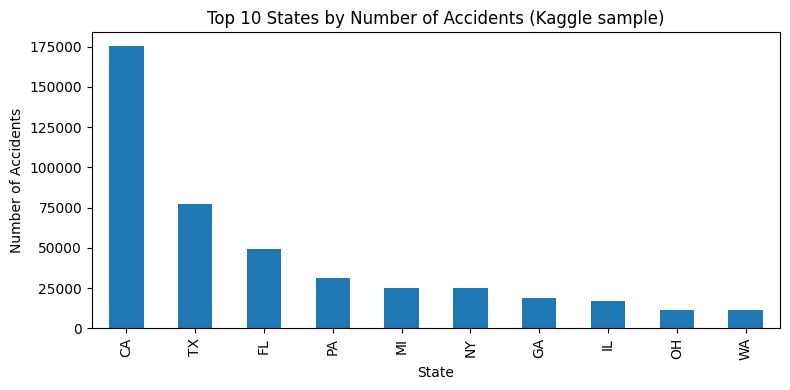


--- Monthly Accident Counts ---
Month
1     38718
2     35798
3     43335
4     45703
5     35662
      ...  
8     38541
9     39565
10    38185
11    46532
12    40655
Name: ID, Length: 12, dtype: int64
Month with highest number of accidents: 6


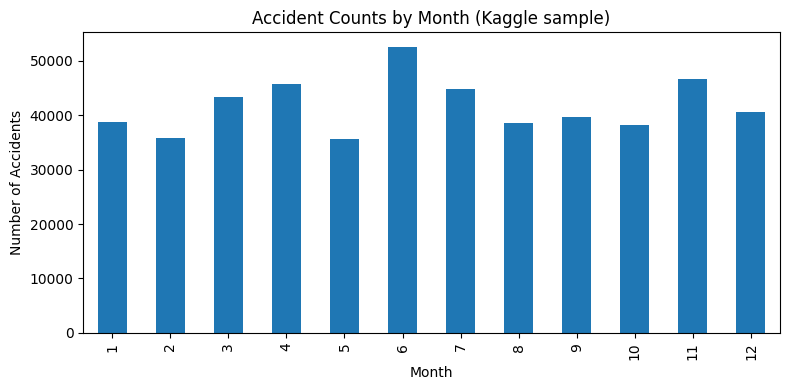


--- Day of Week Accident Counts ---
DayOfWeek
Thursday     90234
Tuesday      89716
Wednesday    89338
Friday       87345
Monday       83912
Saturday     31529
Sunday       27926
Name: count, dtype: int64
Busiest day of the week: Thursday


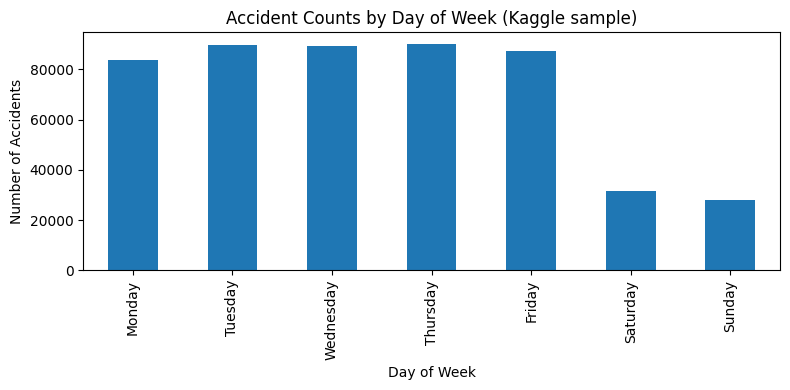


--- Severity Distribution ---
Counts:
 Severity
1       388
2    312159
3    187173
4       280
Name: count, dtype: int64

Proportions:
 Severity
1    0.001
2    0.624
3    0.374
4    0.001
Name: proportion, dtype: float64


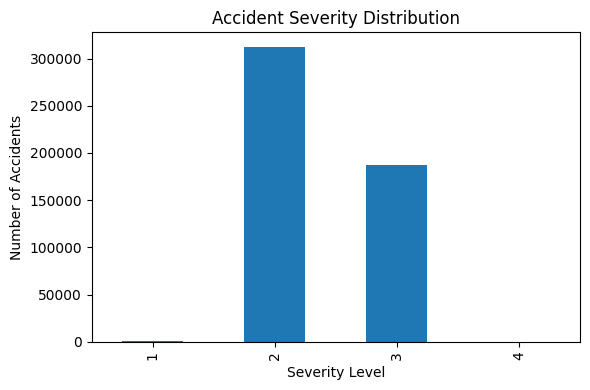

In [24]:
# National accident patterns from Kaggle sample

# 4.1 Top 10 states with the most accidents
top_states = df['State'].value_counts().head(10)

print("--- Top 10 States with Most Accidents ---")
print(top_states)

plt.figure(figsize=(8, 4))
top_states.plot(kind='bar')
plt.title("Top 10 States by Number of Accidents (Kaggle sample)")
plt.xlabel("State")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()


# 4.2 Monthly accident trend
monthly_trend = df.groupby('Month')['ID'].count().sort_index()

print("\n--- Monthly Accident Counts ---")
print(monthly_trend)
print("Month with highest number of accidents:", monthly_trend.idxmax())

plt.figure(figsize=(8, 4))
monthly_trend.plot(kind='bar')
plt.title("Accident Counts by Month (Kaggle sample)")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()


# 4.3 Day-of-week accident pattern
dow_counts = df['DayOfWeek'].value_counts()

print("\n--- Day of Week Accident Counts ---")
print(dow_counts)
print("Busiest day of the week:", dow_counts.idxmax())

# Reorder days for nicer plot
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts_ordered = dow_counts.reindex(dow_order)

plt.figure(figsize=(8, 4))
dow_counts_ordered.plot(kind='bar')
plt.title("Accident Counts by Day of Week (Kaggle sample)")
plt.xlabel("Day of Week")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()


# 4.4 Severity distribution
severity_counts = df['Severity'].value_counts().sort_index()
severity_props  = df['Severity'].value_counts(normalize=True).sort_index()

print("\n--- Severity Distribution ---")
print("Counts:\n", severity_counts)
print("\nProportions:\n", severity_props.round(3))

plt.figure(figsize=(6, 4))
severity_counts.plot(kind='bar')
plt.title("Accident Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()


## ⏰ Step 5 – When do accidents happen? (Time-of-day analysis)

Here we focus on the **time of day** using the `Hour` feature we created:

1. Count how many accidents happen in each hour (0–23).  
2. Find the **peak accident hour** in the national Kaggle sample.  
3. List the **top 5 busiest hours** with readable labels (e.g., “8 AM”).  
4. Visualize the full 24-hour pattern with a bar chart.

This lets us check whether crashes really cluster around **rush hours** in the morning and evening.


=== Accident counts by hour of day (0–23) ===
Hour
0      4892
1      3722
2      3924
3      3202
4      6426
      ...  
19    26113
20    23333
21    14876
22    11366
23     5054
Name: count, Length: 24, dtype: int64

Peak accident hour (24-hour): 8
Peak accident hour (label): 8 AM

Top 5 accident hours (national Kaggle sample):
- 8 AM (hour=8) → 40174 accidents
- 9 AM (hour=9) → 34459 accidents
- 7 AM (hour=7) → 33490 accidents
- 5 PM (hour=17) → 33180 accidents
- 10 AM (hour=10) → 32781 accidents


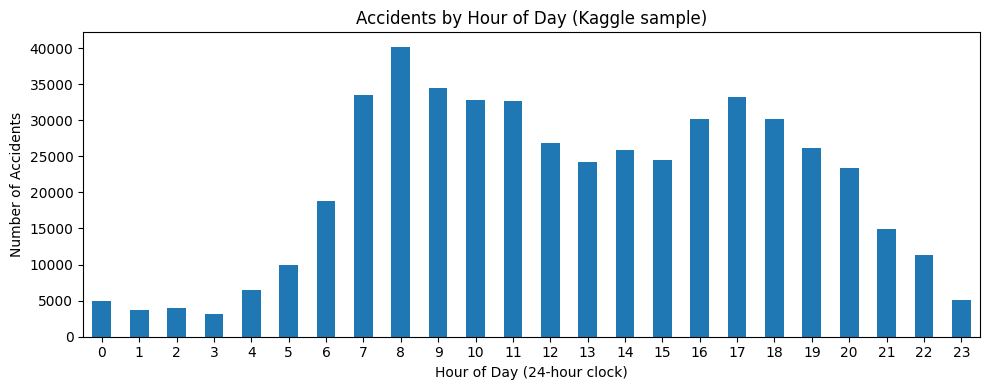

In [25]:
# Time-of-day analysis (national Kaggle sample)

# 5.1 Counting accidents per hour (0–23)
hour_counts = df['Hour'].value_counts().sort_index()

print("=== Accident counts by hour of day (0–23) ===")
print(hour_counts)

# 5.2 Finding peak accident hour
peak_hour = hour_counts.idxmax()
print(f"\nPeak accident hour (24-hour): {peak_hour}")
print(f"Peak accident hour (label): {hour_to_label(peak_hour)}")

# 5.3 Top 5 accident hours
top_hours = df['Hour'].value_counts().sort_values(ascending=False).head(5)

print("\nTop 5 accident hours (national Kaggle sample):")
for h, c in top_hours.items():
    print(f"- {hour_to_label(h)} (hour={h}) → {c} accidents")


# 5.4 Visualization – accidents by hour of day
plt.figure(figsize=(10, 4))
hour_counts.plot(kind='bar')
plt.title("Accidents by Hour of Day (Kaggle sample)")
plt.xlabel("Hour of Day (24-hour clock)")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 🌦️ Step 6 – How does weather relate to accidents?

Now we look at the `Weather_Condition` field in the Kaggle data.

In this step we:

1. Find the **top 10 most common weather conditions** in our sample.  
2. For those conditions, calculate:
   - how many accidents happened, and  
   - the **average severity** of those accidents.  
3. Show the results as:
   - a small summary table, and  
   - a bar chart of accident counts by weather condition.

This helps us see the difference between:
- weather that is **very common** (e.g., clear / partly cloudy), and  
- weather that might be **less frequent but more severe** (e.g., heavy rain or snow).


--- Top 10 Weather Conditions by Frequency ---
Weather_Condition
Clear               205029
Overcast             79031
Mostly Cloudy        66165
Partly Cloudy        46908
Scattered Clouds     45714
Light Rain           20500
Haze                  5884
Rain                  4248
Light Snow            3962
Fair                  2456
Name: count, dtype: int64

--- Accident count & average severity for common weather conditions ---


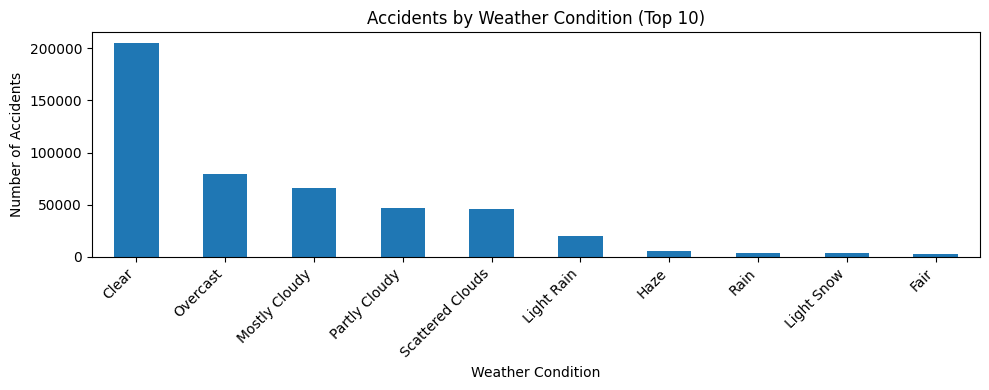

In [26]:
# Weather conditions & severity (Kaggle sample)

# 6.1 Top 10 most frequent weather conditions
top_weather = df['Weather_Condition'].value_counts().head(10)

print("--- Top 10 Weather Conditions by Frequency ---")
print(top_weather)

# Filtering dataset to only those top 10 conditions
common_weather = df[df['Weather_Condition'].isin(top_weather.index)]

# 6.2 For these common conditions, compute count + average severity
severity_common_weather = (
    common_weather
    .groupby('Weather_Condition')['Severity']
    .agg(['count', 'mean'])
    .sort_values(by='count', ascending=False)
)

print("\n--- Accident count & average severity for common weather conditions ---")
severity_common_weather_rounded = severity_common_weather.round(2)
severity_common_weather_rounded.style.background_gradient(cmap="Blues")


# 6.3 Visualization – number of accidents by weather (top 10)
plt.figure(figsize=(10, 4))
severity_common_weather['count'].plot(kind='bar')
plt.title("Accidents by Weather Condition (Top 10)")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 🗽 Step 7 – Focus on New York State (from Kaggle)

So far, we looked at **national patterns**.  
Next, we narrow the Kaggle dataset down to **New York State** only (`State == "NY"`).

In this step we:

1. Create a **New York subset** of the Kaggle data.  
2. Check how many records we have for NY.  
3. Analyze the **time-of-day pattern** just for New York:
   - accident counts by hour  
   - the **peak accident hour** in NY  
4. Visualize the NY hourly pattern with a bar chart.

Later, we’ll connect this New York subset to the **NYC Open Data API** and merge them.


 New York subset created from Kaggle data.
New York shape: 25,067 rows × 48 columns

=== New York (Kaggle) – Accidents by hour of day (0–23) ===
Hour
0     229
1     148
2     154
3     148
4     391
     ... 
19    993
20    721
21    382
22    274
23    180
Name: count, Length: 24, dtype: int64

New York peak accident hour (24-hour): 8
New York peak accident hour (label): 8 AM


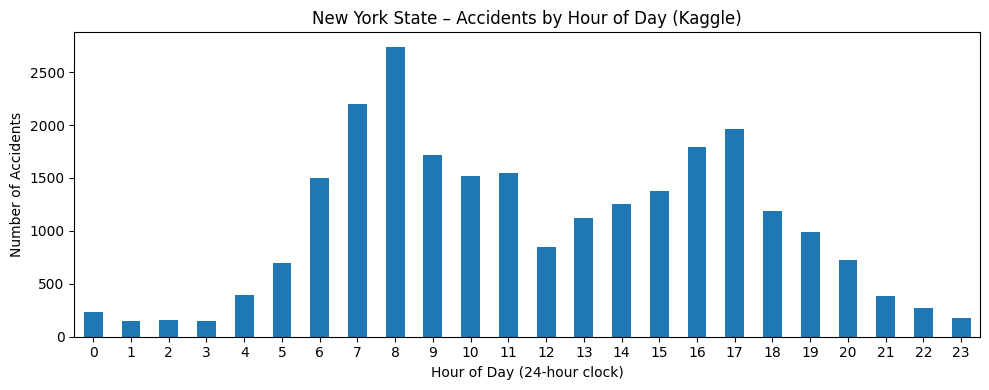

In [27]:
# New York State subset & hourly pattern (Kaggle)

# 7.1 Filtering Kaggle data for New York State only
df_ny = df[df['State'] == 'NY'].copy()

print(" New York subset created from Kaggle data.")
print(f"New York shape: {df_ny.shape[0]:,} rows × {df_ny.shape[1]} columns")

# 7.2 Accident counts by hour (0–23) for New York
ny_hour_counts = df_ny['Hour'].value_counts().sort_index()
ny_peak_hour = ny_hour_counts.idxmax()

print("\n=== New York (Kaggle) – Accidents by hour of day (0–23) ===")
print(ny_hour_counts)

print(f"\nNew York peak accident hour (24-hour): {ny_peak_hour}")
print(f"New York peak accident hour (label): {hour_to_label(ny_peak_hour)}")

# 7.3 Visualization – New York accidents by hour
plt.figure(figsize=(10, 4))
ny_hour_counts.plot(kind='bar')
plt.title("New York State – Accidents by Hour of Day (Kaggle)")
plt.xlabel("Hour of Day (24-hour clock)")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 🗽 Step 8 – Load NYC crash data from the Open Data API (semi-structured JSON)

To complement the Kaggle dataset, we now pull **real crash records from New York City** using the:

> `Motor Vehicle Collisions – Crashes` dataset on NYC Open Data.

In this step we:

1. Call the NYC API endpoint using `requests`.  
2. Load the JSON response into a pandas DataFrame using `json_normalize`.  
3. Quickly inspect:
   - how many rows we received, and  
   - a styled preview of the first few crashes.

This gives us a **city-level view** (boroughs, injuries, pedestrians, cyclists, etc.) that we will later merge with the New York subset from Kaggle.


In [28]:
# Loading NYC crash data from the Open Data API

# NYC Open Data - Motor Vehicle Collisions (Crashes)
nyc_url = "https://data.cityofnewyork.us/resource/h9gi-nx95.json?$limit=5000"

response = requests.get(nyc_url)

if response.status_code != 200:
    print(f"⚠️ API request failed with status code {response.status_code}")
else:
    data_api = response.json()
    
    # Converting JSON list of dicts to DataFrame
    df_api = pd.json_normalize(data_api)
    
    print("NYC crash data loaded from API.")
    print(f"Rows received: {len(df_api):,}")
    print("\nFirst 10 columns:")
    print(list(df_api.columns[:10]))
    
    # Styled preview of first few NYC crash records
    df_api.head().style.set_properties(**{"text-align": "left"})


NYC crash data loaded from API.
Rows received: 5,000

First 10 columns:
['crash_date', 'crash_time', 'on_street_name', 'off_street_name', 'number_of_persons_injured', 'number_of_persons_killed', 'number_of_pedestrians_injured', 'number_of_pedestrians_killed', 'number_of_cyclist_injured', 'number_of_cyclist_killed']


## 🕒 Step 9 – Clean NYC crash data & build time features

The NYC crash data comes from an API as **semi-structured JSON**, so we need to tidy it up.

In this step we:

1. Convert `crash_date` into a proper **datetime** field.  
2. Create a `Year` column so we can later merge with the New York subset from Kaggle.  
3. Combine `crash_date` and `crash_time` into a single `crash_datetime`.  
4. Extract `NYC_Hour` from `crash_datetime` to analyze **time-of-day patterns** in NYC.

At the end, we print a small preview of these new time columns to verify everything looks correct.


In [29]:
# Cleaning NYC crash data & create time features

# 9.1 Convert crash_date to datetime
df_api['crash_date'] = pd.to_datetime(df_api['crash_date'], errors='coerce')

# 9.2 Creating Year (for merging with Kaggle New York subset later)
df_api['Year'] = df_api['crash_date'].dt.year

# 9.3 Combine crash_date + crash_time into a single datetime
#     crash_time is usually in "HH:MM" format as text.
df_api['crash_datetime'] = pd.to_datetime(
    df_api['crash_date'].dt.strftime('%Y-%m-%d') + ' ' + df_api['crash_time'].astype(str),
    errors='coerce'
)

# 9.4 Extract hour of day for NYC crashes
df_api['NYC_Hour'] = df_api['crash_datetime'].dt.hour

print(" NYC time features created: crash_date (datetime), Year, crash_datetime, NYC_Hour")

# Quick preview of the new time-related columns
time_preview = df_api[['crash_date', 'crash_time', 'crash_datetime', 'NYC_Hour']].head(10)
time_preview.style.set_properties(**{"text-align": "left"})


 NYC time features created: crash_date (datetime), Year, crash_datetime, NYC_Hour


,crash_date,crash_time,crash_datetime,NYC_Hour
0,2021-09-11 00:00:00,2:39,2021-09-11 02:39:00,2
1,2022-03-26 00:00:00,11:45,2022-03-26 11:45:00,11
2,2023-11-01 00:00:00,1:29,2023-11-01 01:29:00,1
3,2022-06-29 00:00:00,6:55,2022-06-29 06:55:00,6
4,2022-09-21 00:00:00,13:21,2022-09-21 13:21:00,13
5,2023-04-26 00:00:00,13:30,2023-04-26 13:30:00,13
6,2023-11-01 00:00:00,7:12,2023-11-01 07:12:00,7
7,2023-11-01 00:00:00,8:01,2023-11-01 08:01:00,8
8,2023-04-26 00:00:00,22:20,2023-04-26 22:20:00,22
9,2021-09-11 00:00:00,9:35,2021-09-11 09:35:00,9


## 🧱 Step 10 – Build NYC subset & merge with New York Kaggle data

Now we connect our two worlds:

- **Kaggle (structured)** – New York State accidents  
- **NYC Open Data (semi-structured)** – detailed city crash records  

In this step we:

1. Select a **clean subset of NYC columns** we actually need:
   - Date & time (`crash_date`, `crash_time`, `crash_datetime`, `NYC_Hour`)  
   - Location (`borough`, street names)  
   - Injury / fatality counts (persons, pedestrians, cyclists)  
   - `Year` (for joining)  

2. Use `Year` to **merge**:
   - `df_ny`  → Kaggle accidents filtered to New York State  
   - `df_api_subset` → NYC crashes  

3. Create a `merged` dataset that combines:
   - Kaggle’s fields (including **Severity**, time features, etc.), and  
   - NYC’s detailed injury and borough information.  

4. Quickly inspect the merged shape and a few rows to confirm it looks reasonable.


In [30]:
# Building NYC subset & merge with New York Kaggle data

# 10.1 Selecting useful columns from NYC API data
nyc_cols = [
    'crash_date',
    'crash_time',
    'crash_datetime',
    'NYC_Hour',
    'on_street_name',
    'off_street_name',
    'borough',
    'number_of_persons_injured',
    'number_of_persons_killed',
    'number_of_pedestrians_injured',
    'number_of_pedestrians_killed',
    'number_of_cyclist_injured',
    'number_of_cyclist_killed',
    'Year'
]

df_api_subset = df_api[nyc_cols].copy()

print(" NYC subset created.")
print(f"NYC subset shape: {df_api_subset.shape[0]:,} rows × {df_api_subset.shape[1]} columns")

df_api_subset.head().style.set_properties(**{"text-align": "left"})


# 10.2 Merging New York Kaggle data with NYC data on Year
merged = pd.merge(df_ny, df_api_subset, on='Year', how='inner')

print("\n Merged Kaggle–NY and NYC datasets.")
print(f"Merged shape: {merged.shape[0]:,} rows × {merged.shape[1]} columns")

print("\nSample of merged data (first 5 rows):")
merged.head().style.set_properties(**{"text-align": "left"})


 NYC subset created.
NYC subset shape: 5,000 rows × 14 columns

 Merged Kaggle–NY and NYC datasets.
Merged shape: 13,085 rows × 61 columns

Sample of merged data (first 5 rows):


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Month,Year,Hour,DayOfWeek,crash_date,crash_time,crash_datetime,NYC_Hour,on_street_name,off_street_name,borough,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed
0,A-194257,Source2,3,2016-11-30 16:25:41,2016-11-30 17:10:30,41.139324,-74.169876,0.010000,Right lane blocked due to accident on I-87 Southbound around Exit 15A NY-17.,Route 17,Sloatsburg,Rockland,NY,10974,US,US/Eastern,KCDW,2016-11-30 16:53:00,53.100000,nan,93.000000,29.810000,1.000000,East,11.500000,0.000000,Overcast,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,11,2016,16,Wednesday,2016-04-16 00:00:00,14:20,2016-04-16 14:20:00,14,WEST 17 STREET,BAY 50 STREET,BROOKLYN,0,0,0,0,0,0
1,A-194258,Source2,3,2016-11-30 15:40:06,2016-11-30 17:09:40,41.118748,-74.159744,2.530000,Accident on I-87 Southbound between Exit 14B County Hwy-89 Airmont Rd and Exit 15 I-287.,I-287 S,Suffern,Rockland,NY,10901,US,US/Eastern,KCDW,2016-11-30 15:53:00,53.100000,nan,93.000000,29.830000,1.000000,ENE,8.100000,0.020000,Overcast,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,11,2016,15,Wednesday,2016-04-16 00:00:00,14:20,2016-04-16 14:20:00,14,WEST 17 STREET,BAY 50 STREET,BROOKLYN,0,0,0,0,0,0
2,A-194259,Source2,3,2016-11-30 15:26:18,2016-11-30 16:56:02,41.014034,-73.717239,1.170000,Accident on I-287 Cross Westchester Expy Eastbound between Exit 9A I-684 and Exit 9S-N I-684.,Hutchinson River Pkwy S,White Plains,Westchester,NY,10605,US,US/Eastern,KHPN,2016-11-30 15:56:00,52.000000,nan,93.000000,29.810000,2.000000,East,17.300000,0.150000,Light Rain,False,False,False,False,True,False,False,False,False,False,False,False,False,Day,Day,Day,Day,11,2016,15,Wednesday,2016-04-16 00:00:00,14:20,2016-04-16 14:20:00,14,WEST 17 STREET,BAY 50 STREET,BROOKLYN,0,0,0,0,0,0
3,A-194260,Source2,3,2016-11-30 16:14:11,2016-11-30 16:59:00,41.390369,-73.597969,0.010000,Right hand shoulder blocked due to accident on I-84 Westbound at Exits 20 20N 20S I-684.,I-84 E,Brewster,Putnam,NY,10509,US,US/Eastern,KDXR,2016-11-30 15:53:00,52.000000,nan,89.000000,29.860000,3.000000,East,10.400000,0.050000,Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,11,2016,16,Wednesday,2016-04-16 00:00:00,14:20,2016-04-16 14:20:00,14,WEST 17 STREET,BAY 50 STREET,BROOKLYN,0,0,0,0,0,0
4,A-194261,Source2,3,2016-11-30 16:17:57,2016-11-30 17:02:44,41.390369,-73.597969,0.010000,Right hand shoulder blocked due to accident on I-84 Eastbound at Exits 20 20N 20S I-684.,I-84 E,Brewster,Putnam,NY,10509,US,US/Eastern,KDXR,2016-11-30 15:53:00,52.000000,nan,89.000000,29.860000,3.000000,East,10.400000,0.050000,Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,11,2016,16,Wednesday,2016-04-16 00:00:00,14:20,2016-04-16 14:20:00,14,WEST 17 STREET,BAY 50 STREET,BROOKLYN,0,0,0,0,0,0


## 🏙️ Step 11 – Injuries & fatalities by NYC borough (NYC crash data)

The merged dataset is useful for combining fields, but when we just want
to know **“Where in NYC are the injuries happening?”**, it’s cleaner to
summarize this directly from the **NYC crash dataset (`df_api`)**.

In this step we:

1. Convert the NYC injury / fatality fields to numeric.  
2. Group crashes by **`borough`** and sum:
   - total persons injured / killed  
   - pedestrians injured / killed  
   - cyclists injured / killed  
3. Show a formatted summary table.  
4. Plot a **horizontal bar chart** of total persons injured by borough,
   which is easier to read when presenting.


=== Injuries & Fatalities by Borough (NYC crash data) ===


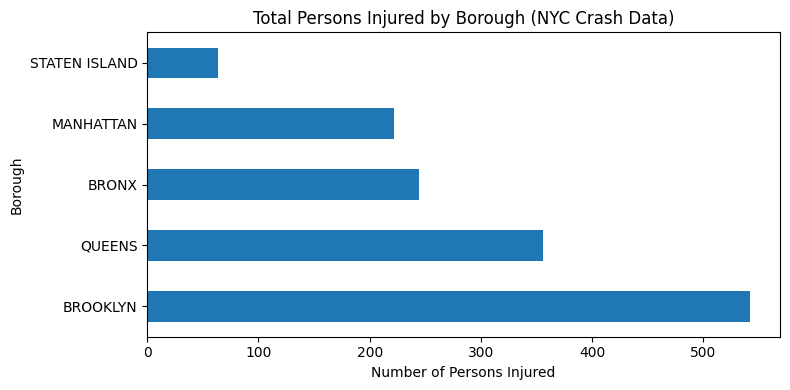

In [31]:
# Injuries & fatalities by NYC borough (using NYC crash data)

# 11.0 Ensure injury / fatality columns are numeric in df_api
injury_cols_api = [
    'number_of_persons_injured',
    'number_of_persons_killed',
    'number_of_pedestrians_injured',
    'number_of_pedestrians_killed',
    'number_of_cyclist_injured',
    'number_of_cyclist_killed'
]

for col in injury_cols_api:
    df_api[col] = pd.to_numeric(df_api[col], errors='coerce')

# 11.1 Group by borough and sum injury/fatality counts
borough_summary = (
    df_api
    .dropna(subset=['borough'])              # drop rows with missing borough
    .groupby('borough')[injury_cols_api]
    .sum()
    .sort_values(by='number_of_persons_injured', ascending=False)
)

print("=== Injuries & Fatalities by Borough (NYC crash data) ===")
borough_summary_rounded = borough_summary.astype("Int64")
borough_summary_rounded.style.background_gradient(cmap="Oranges")


# 11.2 Visualization – total persons injured by borough (horizontal bar)
plt.figure(figsize=(8, 4))
borough_summary['number_of_persons_injured'].plot(kind='barh')
plt.title("Total Persons Injured by Borough (NYC Crash Data)")
plt.xlabel("Number of Persons Injured")
plt.ylabel("Borough")
plt.tight_layout()
plt.show()


## ⏰ Step 12 – When do crashes happen in New York City?

So far we looked at national and New York State patterns.  
Now we focus on **New York City** using the `NYC_Hour` column we created from
`crash_datetime`.

In this step we:

1. Count NYC crashes in each hour of the day (`NYC_Hour`, 0–23).  
2. Find the **peak crash hour** in NYC.  
3. List the **top 5 busiest hours** with readable labels (e.g., “8 AM”).  
4. Plot a bar chart of NYC crashes by hour of day.

This lets us compare NYC’s pattern against the national and New York State
rush-hour patterns.


=== NYC – Crash counts by hour of day (0–23) ===
NYC_Hour
0     257
1     132
2     101
3      89
4      78
     ... 
19    216
20    195
21    214
22    209
23    172
Name: count, Length: 24, dtype: int64

NYC peak crash hour (24-hour): 17
NYC peak crash hour (label): 5 PM

Top 5 crash hours in NYC:
- 5 PM (hour=17) → 350 crashes
- 3 PM (hour=15) → 308 crashes
- 4 PM (hour=16) → 307 crashes
- 6 PM (hour=18) → 307 crashes
- 2 PM (hour=14) → 285 crashes


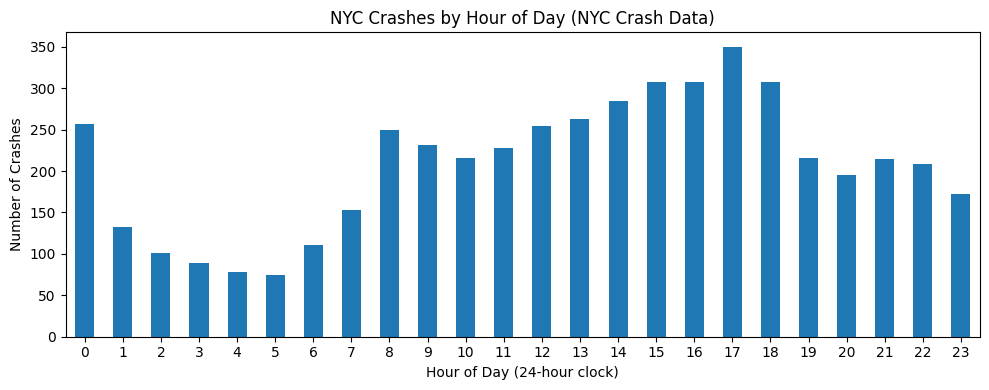

In [32]:
# Time-of-day pattern for New York City (NYC_Hour)

# Keeping only rows with a valid hour
df_api_valid = df_api.dropna(subset=['NYC_Hour']).copy()

# 12.1 Crashing counts by hour (0–23)
nyc_hour_counts = df_api_valid['NYC_Hour'].value_counts().sort_index()
nyc_peak_hour = nyc_hour_counts.idxmax()

print("=== NYC – Crash counts by hour of day (0–23) ===")
print(nyc_hour_counts)

print(f"\nNYC peak crash hour (24-hour): {nyc_peak_hour}")
print(f"NYC peak crash hour (label): {hour_to_label(nyc_peak_hour)}")

# 12.2 Top 5 busiest hours in NYC
nyc_top_hours = df_api_valid['NYC_Hour'].value_counts().sort_values(ascending=False).head(5)
print("\nTop 5 crash hours in NYC:")
for h, c in nyc_top_hours.items():
    print(f"- {hour_to_label(h)} (hour={h}) → {c} crashes")

# 12.3 Visualization – NYC crashes by hour of day
plt.figure(figsize=(10, 4))
nyc_hour_counts.plot(kind='bar')
plt.title("NYC Crashes by Hour of Day (NYC Crash Data)")
plt.xlabel("Hour of Day (24-hour clock)")
plt.ylabel("Number of Crashes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 🔎 Step 13 – What do crash descriptions talk about?

Finally, we look at the free-text **`Description`** field (from the Kaggle data)
inside our **merged New York / NYC dataset**.

In this step we:

1. Clean the `Description` column (replace missing values with empty strings).  
2. Define a small list of **keywords** related to:
   - driver behaviour (`speeding`, `distracted`, `alcohol`)  
   - conditions (`rain`, `snow`, `fog`)  
   - crash mechanics (`collision`, `lane`, `blocked`, `crash`, `accident`)  
3. Use a simple regex search to find these keywords in each description.  
4. Show a few **example rows** with the keywords we detected.  
5. Count how often each keyword appears and plot a **bar chart** of the top ones.

This gives a quick view of the main **themes** that repeatedly show up in crash
descriptions.


Example of keyword extraction (first 15 rows):


,Description,Keywords_Found
0,Right lane blocked due to accident on I-87 Southbound around Exit 15A NY-17.,"['lane', 'blocked', 'accident']"
1,Accident on I-87 Southbound between Exit 14B County Hwy-89 Airmont Rd and Exit 15 I-287.,['accident']
2,Accident on I-287 Cross Westchester Expy Eastbound between Exit 9A I-684 and Exit 9S-N I-684.,['accident']
3,Right hand shoulder blocked due to accident on I-84 Westbound at Exits 20 20N 20S I-684.,"['blocked', 'accident']"
4,Right hand shoulder blocked due to accident on I-84 Eastbound at Exits 20 20N 20S I-684.,"['blocked', 'accident']"
5,Accident pedestrian involved on NY-109 Little East Neck Rd at Railroad Ave.,['accident']
6,Accident pedestrian involved on County Hwy-50 Union Blvd at 4th Ave.,['accident']
7,Right hand shoulder blocked due to accident on I-87 Northbound at Exit 4 Wolf Rd.,"['blocked', 'accident']"
8,Shoulder blocked on exit ramp due to accident on I-787 Northbound at Exits 3 3A 3B 4 US-9.,"['blocked', 'accident']"
9,Accident on I-95 Southbound at Exits 21 22 I-287 Cross Westchester Expy.,['accident']


=== Most common accident-related keywords ===
[('accident', 13047), ('blocked', 7527), ('lane', 3981), ('rain', 402)]


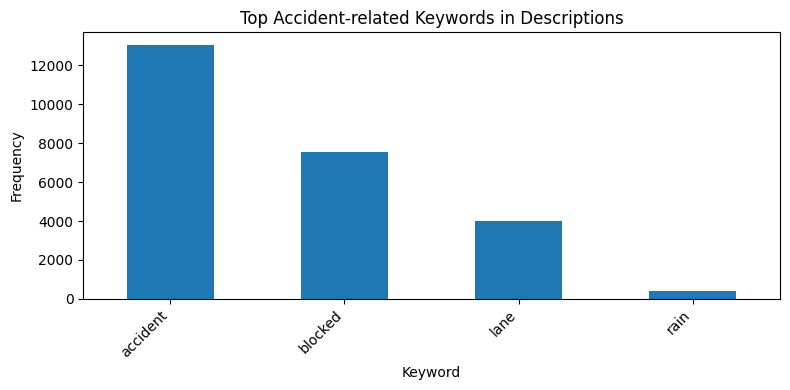

In [36]:
# Keyword analysis on crash descriptions (merged dataset)

# 13.1 Making sure Description is text and not NaN
merged['Description'] = merged['Description'].fillna("").astype(str)

# 13.2 Defining list of keywords to search for
keywords = [
    'speeding', 'distracted', 'alcohol',
    'rain', 'snow', 'fog',
    'collision', 'lane', 'blocked',
    'crash', 'accident'
]

# Build regex pattern like "speeding|distracted|alcohol|..."
pattern = '|'.join(keywords)

# 13.3 Find all keyword matches (case-insensitive) per description
merged['Keywords_Found'] = (
    merged['Description']
    .str.lower()
    .str.findall(pattern)
)

# Show some sample rows
print("Example of keyword extraction (first 15 rows):")
sample_keywords = merged[['Description', 'Keywords_Found']].head(15).style.set_properties(**{"text-align": "left"})
display(sample_keywords)

# 13.4 Counting how often each keyword appears overall
from collections import Counter

all_keywords = [w for sublist in merged['Keywords_Found'] for w in sublist]
keyword_counts = Counter(all_keywords)

print("=== Most common accident-related keywords ===")
print(keyword_counts.most_common(10))

# 13.5 Visualization – top keywords bar chart
top_kw = dict(keyword_counts.most_common(10))

if top_kw:  # only plot if we actually have matches
    plt.figure(figsize=(8, 4))
    pd.Series(top_kw).plot(kind='bar')
    plt.title("Top Accident-related Keywords in Descriptions")
    plt.xlabel("Keyword")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No keywords matched – check the pattern or Description column.")



## 💾 Step 14 – Save cleaned merged dataset

Before finishing the analysis, we save our **merged New York / NYC dataset** so it
can be reused later without re-running all the steps in this notebook.

We export:

- the `merged` DataFrame (Kaggle New York + NYC crash data)  
- as a CSV file named **`cleaned_accident_data.csv`** in the current working folder.


In [34]:
# Step 14: Saving merged data to CSV

output_path = "cleaned_accident_data.csv"
merged.to_csv(output_path, index=False)

print(f"💾 Saved merged dataset as '{output_path}'")


💾 Saved merged dataset as 'cleaned_accident_data.csv'


## Step 15 – Final summary of key insights

In this final step, we generate **talking points** that summarize what we found
from combining the Kaggle and NYC crash datasets.

We highlight:

- overall patterns from the **national Kaggle sample**  
- time-of-day patterns for the **U.S., New York State, and NYC**  
- which **NYC borough** has the most injuries  
- the **most common keyword** in crash descriptions  

These lines are what we can read or paraphrase when presenting the notebook.


In [35]:
# Final summary of insights in table form

# --- National (Kaggle sample) ---
top_state = df['State'].value_counts().idxmax()
avg_severity = df['Severity'].mean().round(2)
national_peak_hour = df['Hour'].value_counts().idxmax()

# --- New York State (Kaggle subset) ---
ny_peak_hour = df_ny['Hour'].value_counts().idxmax()

# --- NYC (API) time-of-day ---
df_api_valid = df_api.dropna(subset=['NYC_Hour']).copy()
nyc_hour_counts = df_api_valid['NYC_Hour'].value_counts().sort_index()
nyc_peak_hour = nyc_hour_counts.idxmax() if len(nyc_hour_counts) > 0 else None

# --- Borough with most injured persons (NYC crash data) ---
injury_cols_api = [
    'number_of_persons_injured',
    'number_of_persons_killed',
    'number_of_pedestrians_injured',
    'number_of_pedestrians_killed',
    'number_of_cyclist_injured',
    'number_of_cyclist_killed'
]

for col in injury_cols_api:
    df_api[col] = pd.to_numeric(df_api[col], errors='coerce')

borough_summary = (
    df_api
    .dropna(subset=['borough'])
    .groupby('borough')[injury_cols_api]
    .sum()
)

borough_most_injured = borough_summary['number_of_persons_injured'].idxmax()

# --- Most common keyword in descriptions (from Step 13) ---
if 'keyword_counts' in globals() and len(keyword_counts) > 0:
    most_common_keyword = keyword_counts.most_common(1)[0][0]
else:
    most_common_keyword = "N/A"

# -------- Build summary table --------
summary_rows = [
    {
        "Insight": "Kaggle sample size after cleaning",
        "Result": f"{len(df):,} accidents"
    },
    {
        "Insight": "Most accident-prone state (Kaggle sample)",
        "Result": top_state
    },
    {
        "Insight": "Average severity (Kaggle sample)",
        "Result": avg_severity
    },
    {
        "Insight": "National peak accident hour",
        "Result": hour_to_label(national_peak_hour)
    },
    {
        "Insight": "New York State peak accident hour",
        "Result": hour_to_label(ny_peak_hour)
    }
]

if nyc_peak_hour is not None:
    summary_rows.append(
        {
            "Insight": "NYC peak crash hour (API data)",
            "Result": hour_to_label(nyc_peak_hour)
        }
    )

summary_rows.extend([
    {
        "Insight": "NYC borough with highest number of injured persons",
        "Result": borough_most_injured
    },
    {
        "Insight": "Most common keyword in crash descriptions",
        "Result": most_common_keyword
    }
])

summary_df = pd.DataFrame(summary_rows)

print("===== Final Summary – Talking Points =====")
summary_df.style.set_properties(**{"text-align": "left"})


===== Final Summary – Talking Points =====


,Insight,Result
0,Kaggle sample size after cleaning,"500,000 accidents"
1,Most accident-prone state (Kaggle sample),CA
2,Average severity (Kaggle sample),2.370000
3,National peak accident hour,8 AM
4,New York State peak accident hour,8 AM
5,NYC peak crash hour (API data),5 PM
6,NYC borough with highest number of injured persons,BROOKLYN
7,Most common keyword in crash descriptions,accident
